![Visual representation of the total events by year from 1919-1962](Graph_SCoData_Events.png)

This Juypter Notebook is a replication study project seeking to replicate the above visual from an article published in the *Journal of Cultural Analytics*. Joshua Kotin and Rebecca Sutton Koeser from Princeton University authored "Shakespeare and Company Project Data Sets" to provide an open dataset about Shakespeare and Company, Sylvia's Beach's bookshop and lending library in interwar Paris. The image above shows the number of total events which occured between the years Beach oberated book lending/buying serives. It is through this visualization that the authors are able to claim that, "Analyzing the number and distribution of events illuminates both the operations of Shakespeare and Company and the completeness of the Beach Papers" (Koeser & Kotin). The peak of the graph is in 1938 with aproxomently 2500 events. These events are either "subscription eventssubscription, renewal, supplement, reimbursement, separate payment) or borrowing event type (borrow, crossed out, generic, gift, periodical subscription, purchase, request)" (Koeser & Kotin). 

This Juypter Notebook aims to replicate this visualization to see if the author's claims that a visualization of the events which occured illistrates the completeness of Beach Papers or not. The data used was obtained from the csv file attached by the authors to their article. In addition, I will investigate what data was removed from the visualization and compare my limitations to the authors' as stated in the limitation section of "Shakespeare and Company Project Data Sets"

I will be using Pandas to read and clean the data due to it's effectivness in reading csv files. Numpy will assist in quantifying my data. MatPlotLib and Seaborn are both visualization packages which will help me replicate the graph.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now let's get an idea on how the data looks like. This can be done by importing the csv file and generating the first 5 lines of the code.

In [2]:
df = pd.read_csv('SCoData_events.csv')
df.head()

/var/folders/g_/n1tb1fyd0xz3bjhstllpd3c40000gn/T/ipykernel_92501/4220628457.py:1: DtypeWarning: Columns (0: item_volume) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('SCoData_events.csv')


,event_type,start_date,end_date,member_ids,member_uris,member_names,member_sort_names,subscription_price_paid,subscription_deposit,subscription_duration,...,item_uri,item_title,item_volume,item_authors,item_year,item_notes,source_type,source_citation,source_manifest,source_image
0,Generic,1920,NaN,linossier-raymonde,https://shakespeareandco.princeton.edu/members...,Raymonde Linossier,"Linossier, Raymonde",NaN,NaN,NaN,...,https://shakespeareandco.princeton.edu/books/b...,Pigs Is Pigs,NaN,"Butler, Ellis Parker",1906.0,NaN,Lending Library Card,"Sylvia Beach, Raymonde Linossier Lending Libra...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif.princeton.edu/loris/figgy_prod/00...
1,Subscription,1921,NaN,garreta-amelie,https://shakespeareandco.princeton.edu/members...,Amélie (Stoecklin) Garreta,"Garreta, Amélie",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Address Book,"Sylvia Beach, Address Book 1919 – 1935, box 69...",NaN,NaN
2,Generic,1922,NaN,walsh-ernest,https://shakespeareandco.princeton.edu/members...,Ernest Walsh,"Walsh, Ernest",NaN,NaN,NaN,...,https://shakespeareandco.princeton.edu/books/b...,The Pretty Lady,NaN,"Bennett, Arnold",1918.0,NaN,Lending Library Card,"Sylvia Beach, Ernest Walsh Lending Library Car...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif.princeton.edu/loris/figgy_prod/af...
3,Subscription,1922,NaN,lincoln-1,https://shakespeareandco.princeton.edu/members...,Mr. Lincoln,"Lincoln, Mr.",NaN,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Address Book,"Sylvia Beach, Address Book 1919 – 1935, box 69...",NaN,NaN
4,Crossed out,1923,NaN,morgan-b-h,https://shakespeareandco.princeton.edu/members...,B. H. Morgan,"Morgan, B. H.",NaN,NaN,NaN,...,https://shakespeareandco.princeton.edu/books/c...,The Riddle of the Sands,NaN,"Childers, Erskine",1903.0,NaN,Lending Library Card,"Sylvia Beach, Mr Morgan Lending Library Card, ...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif-cloud.princeton.edu/iiif/2/1d%2F0...


From this small example, we can see that there is going to be quite a bit of missing data, or NaN. While in the first 5 rows there is no missing data, there is a chance that the other 35551 rows could. It is important that the data we want to work with, which are the years listed in the "start_date" column, is able to be munipulated by pandas so we can create a visualization. To do this, the values in this column must be integers. 

We can find what the data is "start_date" is classified as using this:

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35551 entries, 0 to 35550
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   event_type                  35551 non-null  str    
 1   start_date                  35141 non-null  str    
 2   end_date                    33102 non-null  str    
 3   member_ids                  35551 non-null  str    
 4   member_uris                 35551 non-null  str    
 5   member_names                35551 non-null  str    
 6   member_sort_names           35551 non-null  str    
 7   subscription_price_paid     9109 non-null   float64
 8   subscription_deposit        4092 non-null   float64
 9   subscription_duration       9137 non-null   str    
 10  subscription_duration_days  9140 non-null   float64
 11  subscription_volumes        8738 non-null   float64
 12  subscription_category       1583 non-null   str    
 13  subscription_purchase_date  9895 non-null 

Here we see a problem, the data in the column 'start_date' is seen as strings, or in otherwords, as text. Our goal is to create a bar graph timeline to visualize total events by year. This will pose an issue, as a Python cannot create a timeline out of text. The data in "start_date" has to be converted into numerical/integer format. First let's see how much missing data we have in "start_date".

In [4]:
missing_data = df.isnull().sum()
print(missing_data)

event_type                        0
start_date                      410
end_date                       2449
member_ids                        0
member_uris                       0
member_names                      0
member_sort_names                 0
subscription_price_paid       26442
subscription_deposit          31459
subscription_duration         26414
subscription_duration_days    26411
subscription_volumes          26813
subscription_category         33968
subscription_purchase_date    25656
reimbursement_refund          32710
borrow_status                 14488
borrow_duration_days          15821
purchase_price                34788
currency                      22046
item_uri                      13064
item_title                    13064
item_volume                   34437
item_authors                  15299
item_year                     15297
item_notes                    34013
source_type                       0
source_citation                   0
source_manifest             

There are 410 rows in "start_date" with missing data. Out of the 35141 rows in "start_date", this is quiet a negliable amount. Thus, I will be removing all the rows in "start_date" that are NaN and modifying the orginal dataframe. After, I will verify the new number of rows in my dataset.

In [5]:
df.dropna(subset=['start_date'], inplace=True)
len(df)

35141

Now, there are no more NaN values in the "start_date" columm. Now, it is time to convert turn the dates into this column into a numerical variable instead of strings using datetime

In [6]:
# Convert the column to datetime objects
df['start_date'] = pd.to_datetime(df['start_date'], format='mixed', errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 35141 entries, 0 to 35172
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   event_type                  35141 non-null  str           
 1   start_date                  35141 non-null  datetime64[us]
 2   end_date                    33070 non-null  str           
 3   member_ids                  35141 non-null  str           
 4   member_uris                 35141 non-null  str           
 5   member_names                35141 non-null  str           
 6   member_sort_names           35141 non-null  str           
 7   subscription_price_paid     9109 non-null   float64       
 8   subscription_deposit        4092 non-null   float64       
 9   subscription_duration       9137 non-null   str           
 10  subscription_duration_days  9140 non-null   float64       
 11  subscription_volumes        8738 non-null   float64       
 12  subscr

However, there are a few dates which are erroneous in the "start_date" colum. Some dates do not contain a year, and only the MM-DD. This can be fixed by creating a new column called "start_year". This may have the unwanted effect of assigning events with MM-DD time stamps with the nonexistant year "0". To avoid this, I will modify the code to only include rows from "start_year" with a year above 1900.

In [13]:
df['start_year'] = df['start_date'].dt.year
df.head()
df = df[df["start_year"] > 1900] 
df.head()

,event_type,start_date,end_date,member_ids,member_uris,member_names,member_sort_names,subscription_price_paid,subscription_deposit,subscription_duration,...,item_title,item_volume,item_authors,item_year,item_notes,source_type,source_citation,source_manifest,source_image,start_year
0,Generic,1920-01-01,NaN,linossier-raymonde,https://shakespeareandco.princeton.edu/members...,Raymonde Linossier,"Linossier, Raymonde",NaN,NaN,NaN,...,Pigs Is Pigs,NaN,"Butler, Ellis Parker",1906.0,NaN,Lending Library Card,"Sylvia Beach, Raymonde Linossier Lending Libra...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif.princeton.edu/loris/figgy_prod/00...,1920
1,Subscription,1921-01-01,NaN,garreta-amelie,https://shakespeareandco.princeton.edu/members...,Amélie (Stoecklin) Garreta,"Garreta, Amélie",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Address Book,"Sylvia Beach, Address Book 1919 – 1935, box 69...",NaN,NaN,1921
2,Generic,1922-01-01,NaN,walsh-ernest,https://shakespeareandco.princeton.edu/members...,Ernest Walsh,"Walsh, Ernest",NaN,NaN,NaN,...,The Pretty Lady,NaN,"Bennett, Arnold",1918.0,NaN,Lending Library Card,"Sylvia Beach, Ernest Walsh Lending Library Car...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif.princeton.edu/loris/figgy_prod/af...,1922
3,Subscription,1922-01-01,NaN,lincoln-1,https://shakespeareandco.princeton.edu/members...,Mr. Lincoln,"Lincoln, Mr.",NaN,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Address Book,"Sylvia Beach, Address Book 1919 – 1935, box 69...",NaN,NaN,1922
4,Crossed out,1923-01-01,NaN,morgan-b-h,https://shakespeareandco.princeton.edu/members...,B. H. Morgan,"Morgan, B. H.",NaN,NaN,NaN,...,The Riddle of the Sands,NaN,"Childers, Erskine",1903.0,NaN,Lending Library Card,"Sylvia Beach, Mr Morgan Lending Library Card, ...",https://figgy.princeton.edu/concern/scanned_re...,https://iiif-cloud.princeton.edu/iiif/2/1d%2F0...,1923


drop the year value
find the datetime objects which have a year of 0

In [ ]:
df.dropna(subset=['start_year'], inplace=True)

Now that "start_date" is a cleaned colum, containing viable and readable data, it is time to visualizate the number of events which occur in each year listed

Let's clean the data and confirm that there are only usable years within the 'start_date' colum.

In [8]:
df = df.dropna(subset=['start_year'])
df['start_year'].isna().sum()

np.int64(0)

Using Mat Plot and Seasborn, I will be able to republicate the visualization created by the authors of the article. 

I will be matching the orginal visualization as close as possible. I have have a style of a white gride and ensure the figure is large enough to display all the years at once. Then, the graph will be ploted using "start_year." The x-value is the year and the y-value is the number of events. The goal is to create a timeline of events.

/var/folders/g_/n1tb1fyd0xz3bjhstllpd3c40000gn/T/ipykernel_92501/369597114.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='start_year', palette='viridis', order=df['start_year'].value_counts().index)


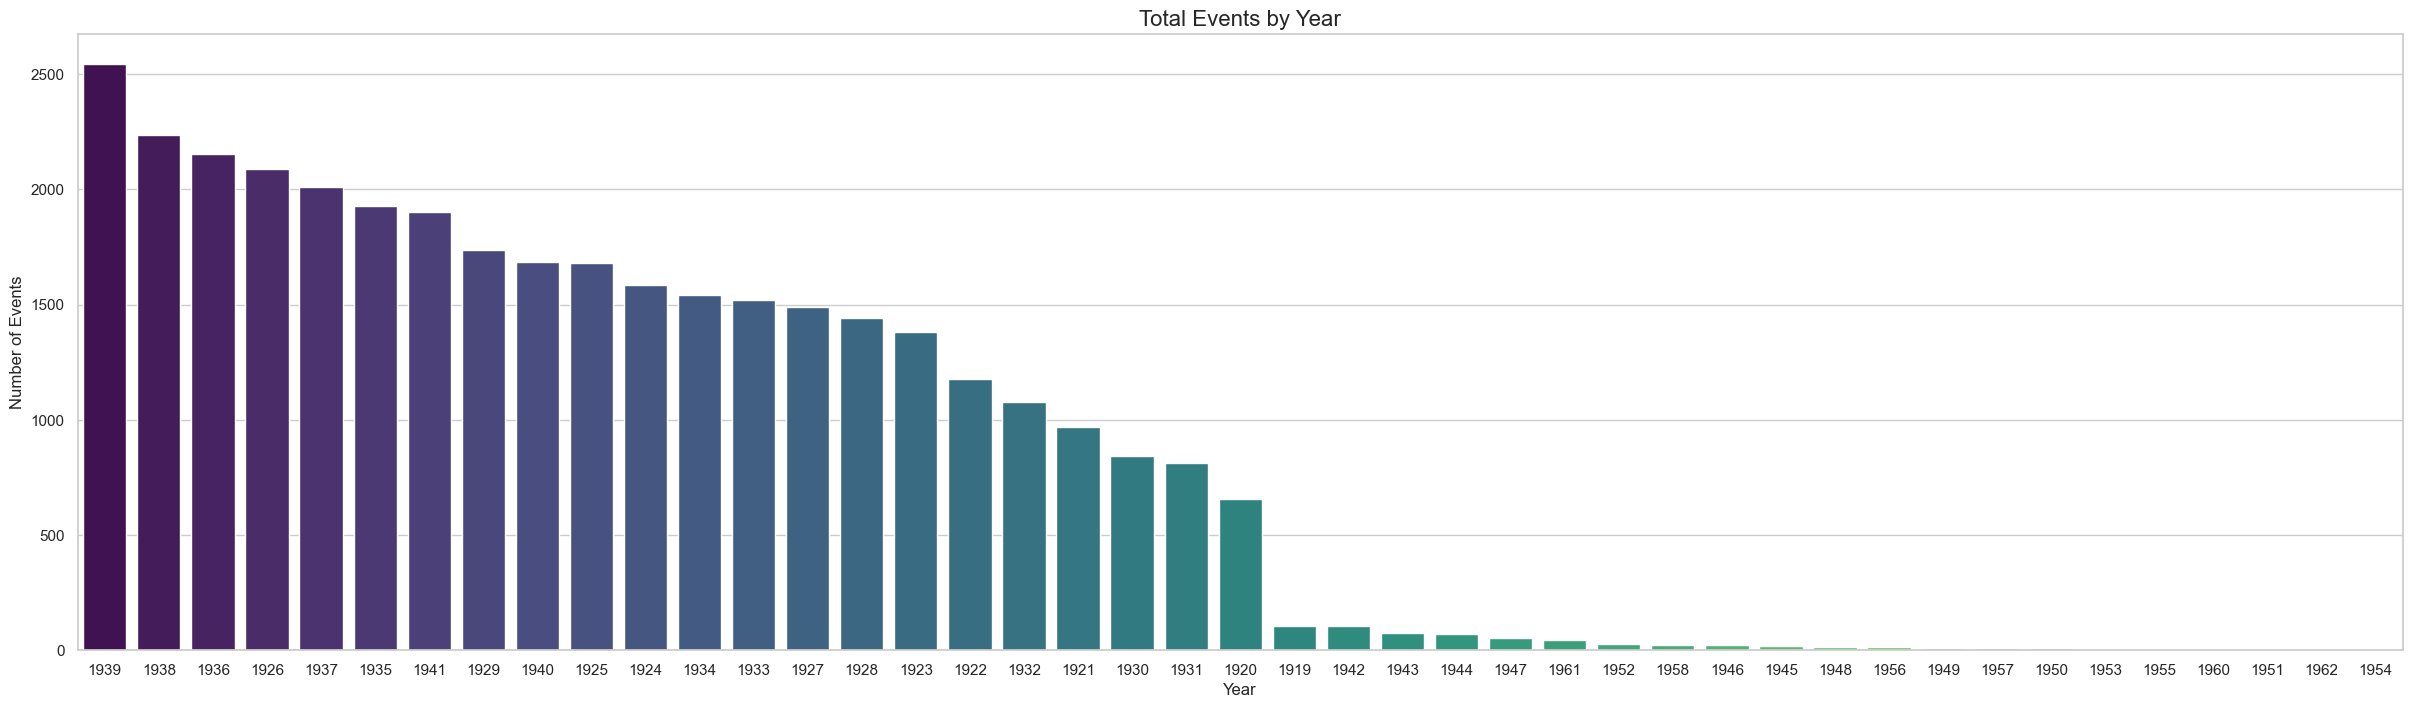

In [14]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the canvas size (10 inches wide, 6 inches tall)
plt.figure(figsize=(30, 8))

# Draw the plot
sns.countplot(data=df, x='start_year', palette='viridis', order=df['start_year'].value_counts().index)

# Add "Argument" (Titles and Labels)
plt.title('Total Events by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Events')

# Show the plot
plt.show()

The graph created started in 1939 instead of 1919, different from the orginal visualization. This bar graph has ordered the years not in a timeline order, but in a greatest to least order. Let's fix this. 

/var/folders/g_/n1tb1fyd0xz3bjhstllpd3c40000gn/T/ipykernel_92501/1887353482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='start_year', palette='viridis', order=sorted(df['start_year'].dropna().unique()))


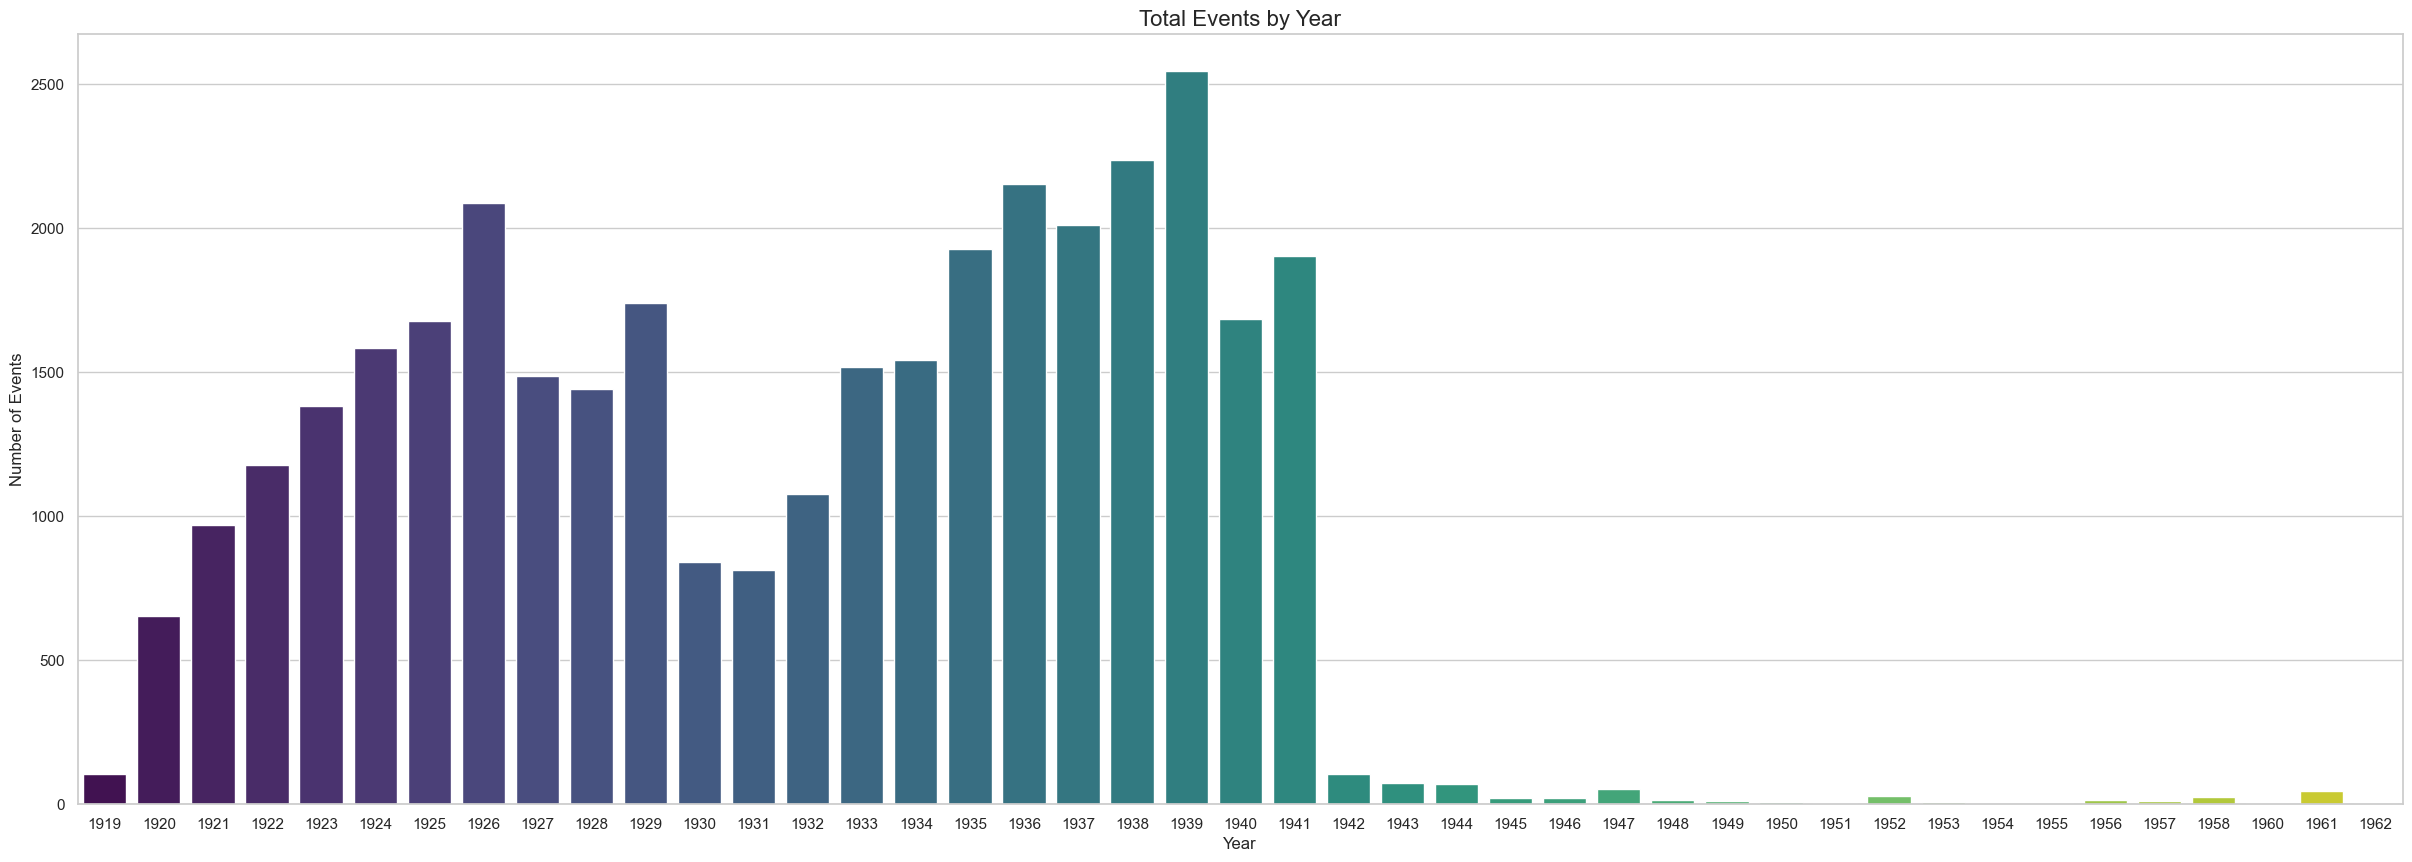

In [15]:
# Set the visual style
sns.set_theme(style="whitegrid")

# Create the canvas size (10 inches wide, 6 inches tall)
plt.figure(figsize=(30, 10))

# Draw the plot
sns.countplot(data=df, x='start_year', palette='viridis', order=sorted(df['start_year'].dropna().unique()))

# Add "Argument" (Titles and Labels)
plt.title('Total Events by Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Events')

# Show the plot
plt.show()

Before, the graph was organized by frequency instead of year. This is because the previous code counted the values and created an index of those values by most to least frequent. As used previously, '.dropna()' is used to drop any remaining missing values, ensuring that the bar graph will be visualized without error. To ensure each year is displayed, '.unique()' displays only different and unique values. 'sorted()' reformats the data in a chronological order. 

Result of Replication Project Study:

The result of my replication study was extreamly similar to the graph made by authors Joshua Kotin and Rebecca Sutton Koeser. Neither visualizations have tally-marks, preventing knowing for certain if the exact values of each bar line up. By completing this replication, I have a greater understanding and appriciation for the work the authors conducted to make this graphical protrayal of the data. I found that making the new row "start_year" was highly effective in finding a solution to create a timeline of events. However, some data had to be excluded to get a visually comprehensible graph. Events without listed years had to be dropped, included events which had missing values is the "start_date" column. Though some event data was excluded, it is a negliable difference, as the rows which contained NaN data were 410 out of 35141. It is unknown if the excluded events which were in a MM-DD format had a negliable impact on the data or not. However, this data had no way to be graph on a yearly timeline, and thus had to be dropped. It was a needed sacrifice in order to find out larger, overall trends of events by year.

 I had access to the same exact dataset used by Kotin and Koeser. This enabled me to visualize the and witness if I would come across any difference between my work and the work published by the authors. My graph shows a similar spike, where the number of overall events reached it's reach in 1939. In addition, my graph corroborates the claim that after 1941, a much smaller number of events occured, reflecting that the store owner continued to loan books after Shakespear and Company closed. Based on what I found, the chart is not misleading and dropped values which are neccessary to be excluded.

 Overall, this replication project was a success without any major discrepancies and validifies the orginal visualization. The main claim that this visualization "[Analyzes]the number and distribution of events [and] illuminates both the operations of Shakespeare and Company and the completeness of the Beach Papers" can be found true(Koeser & Kotin). This is because the graph gives a visual, easily digestable, and accurate representation of the number of events which occur through the years the Shakespeare and Company operated. Periods of peaks and lows can be identified, aiding in our understanding of the history of this book buying/lending service.